# Machine-Learning Forecasting — One-Week-Ahead Dengue Cases

This notebook compares **Random Forest** and **XGBoost** regression for one-week-ahead weekly dengue case forecasting in Maynas, Loreto, Peru.

The experiment is deliberately paired so that improvements can be attributed more clearly to **climate/environmental information**, rather than simply to a more flexible algorithm.

For each algorithm, two specifications are compared:

1. **History-only** — recent dengue incidence + cyclical seasonality.
2. **Climate-enhanced** — the same history features plus selected lagged/rolling environmental predictors.

The final 2021–2023 test period remains untouched. All model comparison and hyperparameter selection in this notebook uses **2018–2020 validation data only**.

## 1. Setup and data loading

Input:

`data/processed/modelling/maynas_dengue_features_1w_ahead.csv`

The engineered feature dataset has already passed an independent audit confirming correct calendar-week lags, rolling calculations, target alignment and no target-week environmental leakage.

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

PROJECT_ROOT = Path.cwd().resolve().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "modelling"
    / "maynas_dengue_features_1w_ahead.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modelling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["week_start_date"] = pd.to_datetime(
    df["week_start_date"],
    errors="raise"
)

df = (
    df
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

Rows: 1,248
Columns: 73
XGBoost available: True


## 2. Fixed chronological split

The modelling design is frozen as:

- **Train:** 2000–2017
- **Validation:** 2018–2020
- **Final test:** 2021–2023

The test period is retained only as a future holdout and is not scored in this notebook.

In [46]:
TRAIN_END = pd.Timestamp("2017-12-31")
VALIDATION_START = pd.Timestamp("2018-01-01")
VALIDATION_END = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")

train_df = df.loc[
    df["week_start_date"] <= TRAIN_END
].copy()

validation_df = df.loc[
    (df["week_start_date"] >= VALIDATION_START)
    & (df["week_start_date"] <= VALIDATION_END)
].copy()

test_df = df.loc[
    df["week_start_date"] >= TEST_START
].copy()

print(f"Train rows:      {len(train_df):,}")
print(f"Validation rows: {len(validation_df):,}")
print(f"Reserved test:   {len(test_df):,}")

Train rows:      936
Validation rows: 156
Reserved test:   156


## 3. Fixed baseline benchmarks

From the previous notebook, the validation benchmarks to beat are:

- **Persistence MAE:** 11.21
- **Persistence RMSE:** 26.62
- **History + seasonality Ridge MAE:** 13.17
- **History + seasonality Ridge RMSE:** 25.33

MAE remains the primary metric. RMSE is retained because large epidemic-week errors are important.

In [47]:
BASELINE_METRICS = pd.DataFrame([
    {
        "model": "Persistence",
        "feature_set": "history-only",
        "MAE": 11.21,
        "RMSE": 26.62,
        "R2": 0.860,
    },
    {
        "model": "History + seasonality Ridge",
        "feature_set": "history-only",
        "MAE": 13.17,
        "RMSE": 25.33,
        "R2": 0.874,
    },
])

BASELINE_METRICS

,model,feature_set,MAE,RMSE,R2
0,Persistence,history-only,11.21,26.62,0.860
1,History + seasonality Ridge,history-only,13.17,25.33,0.874


## 4. Feature specifications

### History-only specification

The history-only model uses:

- cyclical annual seasonality;
- dengue lags at 1, 2, 4 and 8 weeks.

### Climate-enhanced specification

The climate-enhanced model uses the same history features plus a deliberately restrained set of environmental predictors. The aim is to preserve each environmental domain while avoiding an unnecessarily large 54-feature model.

Selected predictors include:

- rainfall lag and rolling accumulation;
- temperature lag and rolling mean;
- humidity lag and rolling mean;
- wind lag and rolling mean;
- pressure lag and rolling mean;
- NDVI lag and rolling mean.

All environmental predictors describe conditions observed **before** the target week.

In [48]:
HISTORY_FEATURES = [
    "week_sin",
    "week_cos",
    "dengue_cases_lag1",
    "dengue_cases_lag2",
    "dengue_cases_lag4",
    "dengue_cases_lag8",
]

CLIMATE_FEATURES = [
    "precip_sum_mm_lag1",
    "precip_sum_mm_lag4",
    "precip_sum_mm_prev4w_sum",

    "temperature_c_mean_lag1",
    "temperature_c_mean_lag8",
    "temperature_c_mean_prev4w_mean",

    "specific_humidity_kgkg_mean_lag1",
    "relative_humidity_pct_mean_prev4w_mean",

    "wind_speed_ms_mean_lag1",
    "wind_speed_ms_mean_lag12",
    "wind_speed_ms_mean_prev4w_mean",

    "surface_pressure_hpa_mean_lag1",
    "surface_pressure_hpa_mean_lag8",
    "surface_pressure_hpa_mean_prev4w_mean",

    "ndvi_mean_weekly_lag1",
    "ndvi_mean_weekly_lag12",
    "ndvi_mean_weekly_prev4w_mean",
]

CLIMATE_ENHANCED_FEATURES = HISTORY_FEATURES + CLIMATE_FEATURES

for feature in CLIMATE_ENHANCED_FEATURES:
    if feature not in df.columns:
        raise ValueError(f"Required feature missing: {feature}")

print(f"History-only features:     {len(HISTORY_FEATURES)}")
print(f"Climate-enhanced features: {len(CLIMATE_ENHANCED_FEATURES)}")

History-only features:     6
Climate-enhanced features: 23


### Why these climate features are restrained

This notebook does **not** automatically use every lag created during feature engineering.

The candidate set is reduced because:

- the dataset contains only 1,248 observations;
- EDA showed substantial predictor redundancy;
- some lag maxima may reflect shared seasonality rather than a causal delay;
- a smaller feature set makes the comparison easier to interpret and reduces overfitting risk.

This is a development specification, not a final causal model.

## 5. Prepare common modelling samples

To make the history-only versus climate-enhanced comparison fair **within each algorithm**, both versions are evaluated on the same validation rows.

Therefore, the paired comparison below uses rows where the full climate-enhanced feature set is available.

In [49]:
all_required = ["week_start_date", "dengue_cases"] + CLIMATE_ENHANCED_FEATURES

train_model = train_df[all_required].dropna().copy()
validation_model = validation_df[all_required].dropna().copy()

print(f"Training rows used for paired comparison:   {len(train_model):,}")
print(f"Validation rows used for paired comparison: {len(validation_model):,}")

Training rows used for paired comparison:   905
Validation rows used for paired comparison: 156


## 6. Metrics and helper functions

In [50]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def clip_nonnegative(values):
    return np.clip(
        np.asarray(values, dtype=float),
        a_min=0,
        a_max=None,
    )

def evaluate_model(model, feature_names, model_name, feature_set_name):
    model.fit(
        train_model[feature_names],
        train_model["dengue_cases"],
    )

    raw_prediction = model.predict(
        validation_model[feature_names]
    )

    prediction = clip_nonnegative(raw_prediction)

    metrics = regression_metrics(
        validation_model["dengue_cases"],
        prediction,
    )

    prediction_df = validation_model[
        ["week_start_date", "dengue_cases"]
    ].copy()

    prediction_df["prediction"] = prediction
    prediction_df["residual"] = (
        prediction_df["dengue_cases"]
        - prediction_df["prediction"]
    )
    prediction_df["model"] = model_name
    prediction_df["feature_set"] = feature_set_name

    return metrics, prediction_df, model

## 7. Random Forest

A small manual grid is used rather than an exhaustive hyperparameter search. This keeps model development proportionate to the dataset size and assessment scope.

Candidate settings vary:

- number of trees;
- maximum tree depth;
- minimum samples per leaf.

The same candidate settings are tested for history-only and climate-enhanced versions.

In [51]:
RF_CONFIGS = [
    {
        "name": "RF_1",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
    },
    {
        "name": "RF_2",
        "n_estimators": 300,
        "max_depth": 8,
        "min_samples_leaf": 2,
    },
    {
        "name": "RF_3",
        "n_estimators": 500,
        "max_depth": 6,
        "min_samples_leaf": 3,
    },
]

rf_results = []
rf_predictions = {}
rf_fitted_models = {}

for feature_set_name, feature_names in {
    "history-only": HISTORY_FEATURES,
    "history+climate": CLIMATE_ENHANCED_FEATURES,
}.items():

    for config in RF_CONFIGS:

        model = RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            random_state=42,
            n_jobs=-1,
        )

        metrics, prediction_df, fitted = evaluate_model(
            model,
            feature_names,
            config["name"],
            feature_set_name,
        )

        result = {
            "algorithm": "Random Forest",
            "configuration": config["name"],
            "feature_set": feature_set_name,
            **metrics,
        }

        rf_results.append(result)

        key = (config["name"], feature_set_name)
        rf_predictions[key] = prediction_df
        rf_fitted_models[key] = fitted

rf_results_df = pd.DataFrame(rf_results).sort_values(
    ["feature_set", "MAE"]
)

rf_results_df

,algorithm,configuration,feature_set,MAE,RMSE,R2
5,Random Forest,RF_3,history+climate,11.096350,22.568208,0.899668
4,Random Forest,RF_2,history+climate,11.099182,21.731996,0.906965
3,Random Forest,RF_1,history+climate,11.116346,22.467189,0.900564
0,Random Forest,RF_1,history-only,12.156667,24.090950,0.885672
1,Random Forest,RF_2,history-only,12.614915,27.624502,0.849674
2,Random Forest,RF_3,history-only,12.742885,29.563467,0.827830


In [52]:
best_rf_history = (
    rf_results_df[
        rf_results_df["feature_set"] == "history-only"
    ]
    .sort_values("MAE")
    .iloc[0]
)

best_rf_climate = (
    rf_results_df[
        rf_results_df["feature_set"] == "history+climate"
    ]
    .sort_values("MAE")
    .iloc[0]
)

pd.DataFrame([
    best_rf_history,
    best_rf_climate,
])

,algorithm,configuration,feature_set,MAE,RMSE,R2
0,Random Forest,RF_1,history-only,12.156667,24.090950,0.885672
5,Random Forest,RF_3,history+climate,11.096350,22.568208,0.899668


### Interpretation — Random Forest

The paired Random Forest comparison provides initial evidence that environmental variables can add predictive value.

The best history-only configuration (`RF_1`) achieved **MAE 12.16** and **RMSE 24.09**. Adding the selected climate/environmental predictors improved the best Random Forest result (`RF_3`) to **MAE 11.10** and **RMSE 22.57**.

This corresponds to approximately:

- **8.7% lower MAE**;
- **6.3% lower RMSE**.

The improvement is meaningful because the algorithm family is held constant: the difference is therefore associated with the additional climate/environmental information rather than simply switching to a more flexible modelling technique.

The climate-enhanced Random Forest also narrowly improves on the persistence benchmark of MAE 11.21, although the difference is small. Its larger RMSE improvement suggests that the main benefit may come from reducing some of the larger forecast errors rather than uniformly improving every week.


## 8. XGBoost

As with Random Forest, a deliberately small manual grid is used.

In [53]:
XGB_CONFIGS = [
    {
        "name": "XGB_1",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
    },
    {
        "name": "XGB_2",
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
    },
    {
        "name": "XGB_3",
        "n_estimators": 300,
        "max_depth": 2,
        "learning_rate": 0.05,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
    },
]

xgb_results = []
xgb_predictions = {}
xgb_fitted_models = {}

if XGBOOST_AVAILABLE:

    for feature_set_name, feature_names in {
        "history-only": HISTORY_FEATURES,
        "history+climate": CLIMATE_ENHANCED_FEATURES,
    }.items():

        for config in XGB_CONFIGS:

            model = XGBRegressor(
                objective="reg:squarederror",
                n_estimators=config["n_estimators"],
                max_depth=config["max_depth"],
                learning_rate=config["learning_rate"],
                subsample=config["subsample"],
                colsample_bytree=config["colsample_bytree"],
                random_state=42,
                n_jobs=-1,
            )

            metrics, prediction_df, fitted = evaluate_model(
                model,
                feature_names,
                config["name"],
                feature_set_name,
            )

            result = {
                "algorithm": "XGBoost",
                "configuration": config["name"],
                "feature_set": feature_set_name,
                **metrics,
            }

            xgb_results.append(result)

            key = (config["name"], feature_set_name)
            xgb_predictions[key] = prediction_df
            xgb_fitted_models[key] = fitted

    xgb_results_df = pd.DataFrame(xgb_results).sort_values(
        ["feature_set", "MAE"]
    )

    display(xgb_results_df)

else:
    xgb_results_df = pd.DataFrame(
        columns=[
            "algorithm",
            "configuration",
            "feature_set",
            "MAE",
            "RMSE",
            "R2",
        ]
    )

,algorithm,configuration,feature_set,MAE,RMSE,R2
5,XGBoost,XGB_3,history+climate,11.196752,21.560116,0.908431
3,XGBoost,XGB_1,history+climate,12.029887,22.619771,0.899209
4,XGBoost,XGB_2,history+climate,12.148208,22.963057,0.896126
2,XGBoost,XGB_3,history-only,10.555791,21.101726,0.912283
1,XGBoost,XGB_2,history-only,10.976329,21.420489,0.909613
0,XGBoost,XGB_1,history-only,11.008091,21.323065,0.910433


In [54]:
if XGBOOST_AVAILABLE:

    best_xgb_history = (
        xgb_results_df[
            xgb_results_df["feature_set"] == "history-only"
        ]
        .sort_values("MAE")
        .iloc[0]
    )

    best_xgb_climate = (
        xgb_results_df[
            xgb_results_df["feature_set"] == "history+climate"
        ]
        .sort_values("MAE")
        .iloc[0]
    )

    display(
        pd.DataFrame([
            best_xgb_history,
            best_xgb_climate,
        ])
    )

,algorithm,configuration,feature_set,MAE,RMSE,R2
2,XGBoost,XGB_3,history-only,10.555791,21.101726,0.912283
5,XGBoost,XGB_3,history+climate,11.196752,21.560116,0.908431


### Interpretation — XGBoost

XGBoost produced the strongest overall validation performance, but the effect of climate variables differs from Random Forest.

The best **history-only XGBoost (`XGB_3`)** achieved:

- **MAE 10.56**
- **RMSE 21.10**
- **R² 0.912**

The corresponding climate-enhanced `XGB_3` produced:

- **MAE 11.20**
- **RMSE 21.56**
- **R² 0.908**

Therefore, adding climate/environmental variables slightly **reduced overall XGBoost validation performance**. This is an important result: climate information does not automatically improve forecasting for every algorithm.

The history-only XGBoost is currently the strongest model on all three overall validation metrics.


## 9. Compare all validation models against the fixed baselines

The principal question is whether the climate-enhanced model improves on:

1. the **same algorithm with history only**; and
2. the **persistence MAE benchmark of 11.21**.

This distinction is essential. If a climate-enhanced XGBoost model beats Ridge, but history-only XGBoost performs equally well, the gain should be attributed mainly to model flexibility rather than climate information.

In [55]:
ml_results_df = pd.concat(
    [
        rf_results_df,
        xgb_results_df,
    ],
    ignore_index=True,
)

best_ml_by_group = (
    ml_results_df
    .sort_values("MAE")
    .groupby(
        ["algorithm", "feature_set"],
        as_index=False
    )
    .first()
)

comparison_table = pd.concat(
    [
        BASELINE_METRICS.assign(
            algorithm="Baseline",
            configuration=BASELINE_METRICS["model"]
        )[
            [
                "algorithm",
                "configuration",
                "feature_set",
                "MAE",
                "RMSE",
                "R2",
            ]
        ],
        best_ml_by_group[
            [
                "algorithm",
                "configuration",
                "feature_set",
                "MAE",
                "RMSE",
                "R2",
            ]
        ],
    ],
    ignore_index=True,
)

comparison_table.sort_values("MAE")

,algorithm,configuration,feature_set,MAE,RMSE,R2
5,XGBoost,XGB_3,history-only,10.555791,21.101726,0.912283
2,Random Forest,RF_3,history+climate,11.096350,22.568208,0.899668
4,XGBoost,XGB_3,history+climate,11.196752,21.560116,0.908431
0,Baseline,Persistence,history-only,11.210000,26.620000,0.860000
3,Random Forest,RF_1,history-only,12.156667,24.090950,0.885672
1,Baseline,History + seasonality Ridge,history-only,13.170000,25.330000,0.874000


### Interpretation — overall model comparison

The validation ranking shows that **XGBoost with dengue history only is currently the strongest overall model**.

Its MAE of 10.56 improves on the persistence benchmark of 11.21 by approximately **5.8%**, while its RMSE of 21.10 is approximately **20.7% lower** than persistence.

The climate-enhanced Random Forest is the second-best model by MAE, followed closely by climate-enhanced XGBoost.

This means two separate findings should be distinguished:

1. **Machine learning improves forecasting beyond simple persistence**, particularly XGBoost.
2. **Climate contribution is model-dependent** rather than universally beneficial.

This distinction is important for the project's hypotheses and prevents improvements caused by algorithm flexibility from being incorrectly attributed to climate variables.


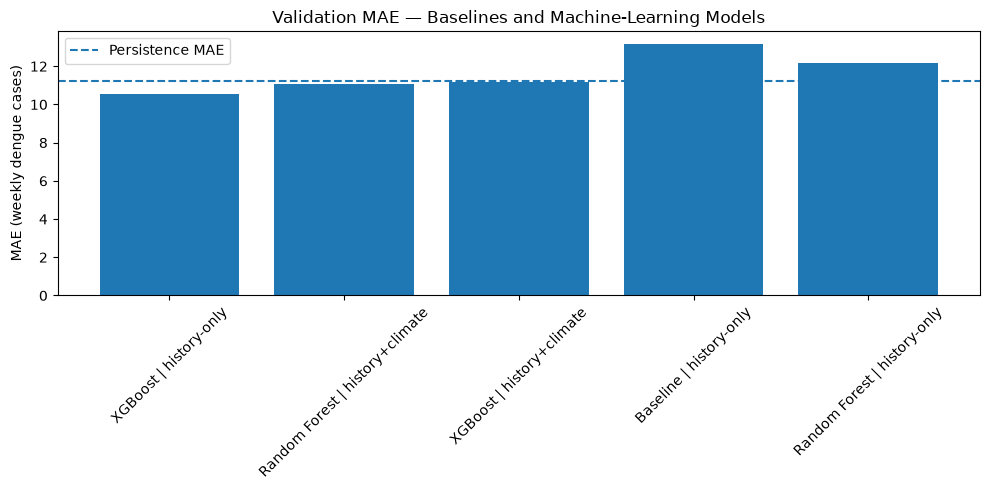

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_df = (
    comparison_table
    .sort_values("MAE")
    .copy()
)

labels = (
    plot_df["algorithm"]
    + " | "
    + plot_df["feature_set"]
)

ax.bar(
    labels,
    plot_df["MAE"]
)

ax.axhline(
    11.21,
    linestyle="--",
    label="Persistence MAE"
)

ax.set_title("Validation MAE — Baselines and Machine-Learning Models")
ax.set_ylabel("MAE (weekly dengue cases)")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## 10. Quantify the incremental value of climate features

For each algorithm, calculate the change from history-only to history + climate.

A negative MAE or RMSE difference means the climate-enhanced specification improved validation performance.

In [57]:
incremental_rows = []

for algorithm in ["Random Forest", "XGBoost"]:

    subset = best_ml_by_group[
        best_ml_by_group["algorithm"] == algorithm
    ]

    if len(subset) < 2:
        continue

    history = subset[
        subset["feature_set"] == "history-only"
    ].iloc[0]

    climate = subset[
        subset["feature_set"] == "history+climate"
    ].iloc[0]

    incremental_rows.append({
        "algorithm": algorithm,
        "history_MAE": history["MAE"],
        "climate_MAE": climate["MAE"],
        "MAE_change": climate["MAE"] - history["MAE"],
        "MAE_pct_change": (
            (climate["MAE"] - history["MAE"])
            / history["MAE"]
            * 100
        ),
        "history_RMSE": history["RMSE"],
        "climate_RMSE": climate["RMSE"],
        "RMSE_change": climate["RMSE"] - history["RMSE"],
        "RMSE_pct_change": (
            (climate["RMSE"] - history["RMSE"])
            / history["RMSE"]
            * 100
        ),
    })

incremental_climate_value = pd.DataFrame(
    incremental_rows
)

incremental_climate_value

,algorithm,history_MAE,climate_MAE,MAE_change,MAE_pct_change,history_RMSE,climate_RMSE,RMSE_change,RMSE_pct_change
0,Random Forest,12.156667,11.096350,-1.060317,-8.722102,24.090950,22.568208,-1.522743,-6.320807
1,XGBoost,10.555791,11.196752,0.640962,6.072134,21.101726,21.560116,0.458390,2.172286


### Interpretation — incremental climate contribution

The paired climate comparison gives a mixed result.

For **Random Forest**, adding climate/environmental variables reduced MAE by **8.72%** and RMSE by **6.32%**. This supports the idea that climate contains useful incremental information for this model.

For **XGBoost**, adding climate increased MAE by **6.07%** and RMSE by **2.17%**. This indicates that the same environmental feature set does not improve overall performance when the model is already capturing non-linear structure effectively from recent dengue history.

Therefore, H1 should not be framed as simply supported or rejected at this stage. A more accurate interpretation is that the predictive contribution of climate is **conditional on model structure and potentially on incidence level**.


## 11. Higher-incidence validation performance

The full-series 95th-percentile threshold of 179.30 cases is retained only as a descriptive way to inspect whether models cope with high-incidence weeks.

It is not used as a classification target.

In [58]:
HIGH_INCIDENCE_THRESHOLD = 179.30

def incidence_error_summary(prediction_df, algorithm, configuration, feature_set):
    temp = prediction_df.copy()

    temp["absolute_error"] = (
        temp["dengue_cases"] - temp["prediction"]
    ).abs()

    temp["incidence_group"] = np.where(
        temp["dengue_cases"] >= HIGH_INCIDENCE_THRESHOLD,
        "Higher-incidence weeks",
        "Other weeks",
    )

    result = (
        temp
        .groupby("incidence_group", as_index=False)
        .agg(
            weeks=("dengue_cases", "size"),
            mean_actual_cases=("dengue_cases", "mean"),
            MAE=("absolute_error", "mean"),
        )
    )

    result["algorithm"] = algorithm
    result["configuration"] = configuration
    result["feature_set"] = feature_set

    return result

incidence_summaries = []

# Best RF models
for feature_set_name, best_row in [
    ("history-only", best_rf_history),
    ("history+climate", best_rf_climate),
]:
    key = (best_row["configuration"], feature_set_name)
    incidence_summaries.append(
        incidence_error_summary(
            rf_predictions[key],
            "Random Forest",
            best_row["configuration"],
            feature_set_name,
        )
    )

# Best XGB models
if XGBOOST_AVAILABLE:
    for feature_set_name, best_row in [
        ("history-only", best_xgb_history),
        ("history+climate", best_xgb_climate),
    ]:
        key = (best_row["configuration"], feature_set_name)
        incidence_summaries.append(
            incidence_error_summary(
                xgb_predictions[key],
                "XGBoost",
                best_row["configuration"],
                feature_set_name,
            )
        )

incidence_error_table = pd.concat(
    incidence_summaries,
    ignore_index=True,
)

incidence_error_table[
    [
        "algorithm",
        "configuration",
        "feature_set",
        "incidence_group",
        "weeks",
        "mean_actual_cases",
        "MAE",
    ]
]

,algorithm,configuration,feature_set,incidence_group,weeks,mean_actual_cases,MAE
0,Random Forest,RF_1,history-only,Higher-incidence weeks,11,276.272727,67.103030
1,Random Forest,RF_1,history-only,Other weeks,145,27.144828,7.988322
2,Random Forest,RF_3,history+climate,Higher-incidence weeks,11,276.272727,46.609091
3,Random Forest,RF_3,history+climate,Other weeks,145,27.144828,8.402280
4,XGBoost,XGB_3,history-only,Higher-incidence weeks,11,276.272727,51.017789
5,XGBoost,XGB_3,history-only,Other weeks,145,27.144828,7.486260
6,XGBoost,XGB_3,history+climate,Higher-incidence weeks,11,276.272727,45.292808
7,XGBoost,XGB_3,history+climate,Other weeks,145,27.144828,8.610155


### Interpretation — performance during higher-incidence weeks

The higher-incidence analysis reveals an important pattern that is obscured by overall MAE.

For the 11 validation weeks above the descriptive 95th-percentile threshold:

- Random Forest history-only MAE: **67.10**
- Random Forest + climate MAE: **46.61**
- XGBoost history-only MAE: **51.02**
- XGBoost + climate MAE: **45.29**

Climate therefore substantially improves forecasts during unusually high-incidence weeks for **both** machine-learning algorithms.

However, the opposite pattern appears during the other 145 validation weeks:

- Random Forest history-only: **7.99 MAE**
- Random Forest + climate: **8.40 MAE**
- XGBoost history-only: **7.49 MAE**
- XGBoost + climate: **8.61 MAE**

This suggests that environmental predictors may be particularly useful when incidence is elevated or changing rapidly, while recent dengue history alone is sufficient for many ordinary weeks.

That interpretation remains exploratory until it is tested on the untouched 2021–2023 holdout.


## 12. Plot the best climate-enhanced validation forecasts

In [59]:
best_climate_candidates = best_ml_by_group[
    best_ml_by_group["feature_set"] == "history+climate"
].sort_values("MAE")

best_climate_candidates

,algorithm,feature_set,configuration,MAE,RMSE,R2
0,Random Forest,history+climate,RF_3,11.096350,22.568208,0.899668
2,XGBoost,history+climate,XGB_3,11.196752,21.560116,0.908431


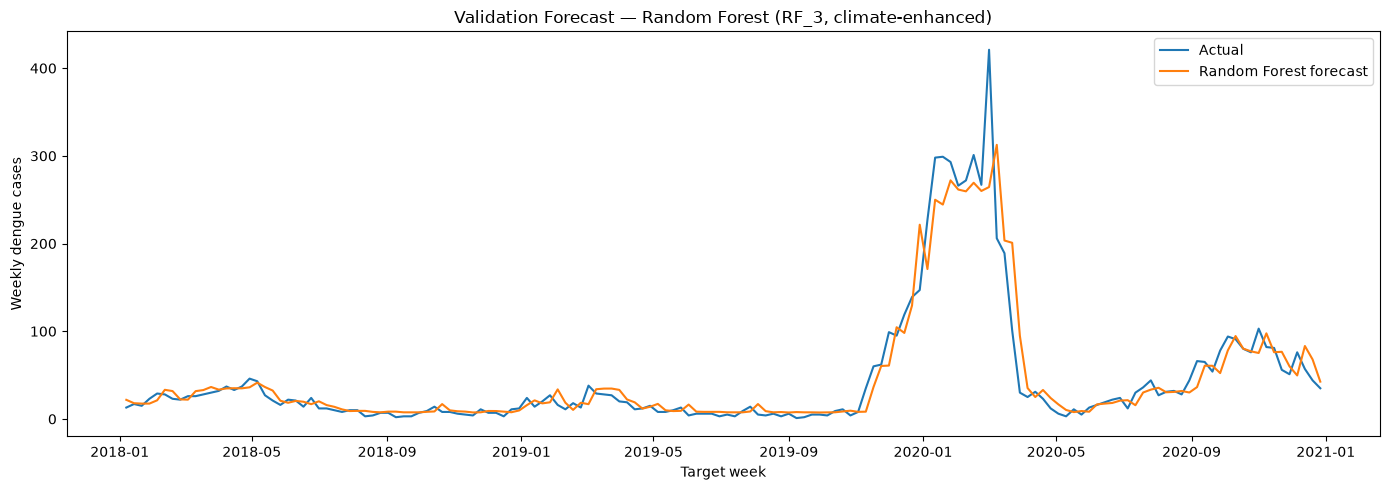

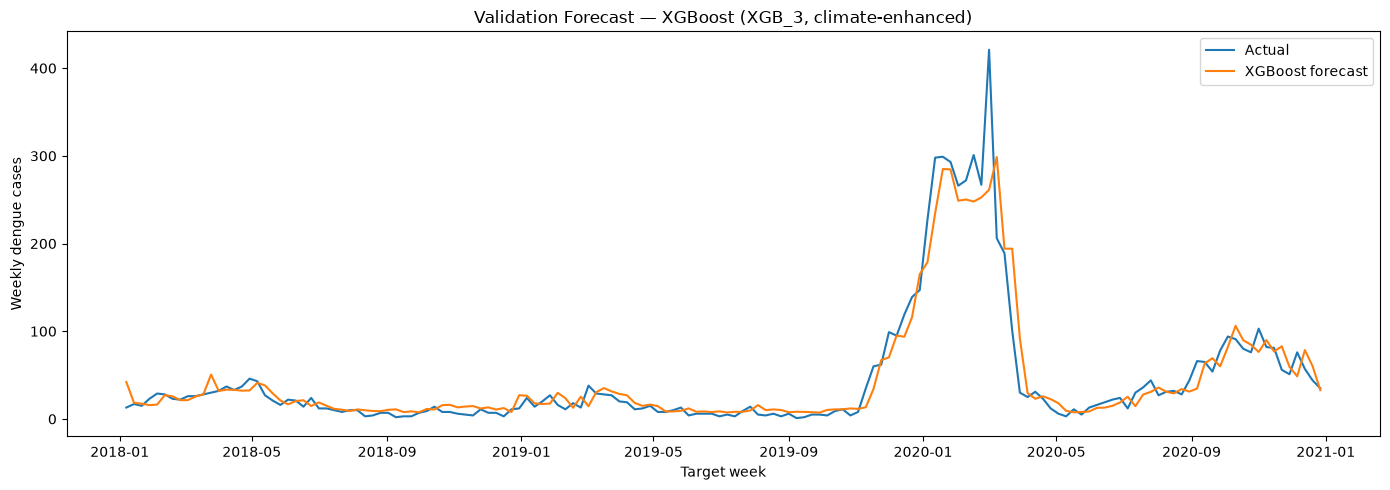

In [60]:
for _, row in best_climate_candidates.iterrows():

    algorithm = row["algorithm"]
    configuration = row["configuration"]

    if algorithm == "Random Forest":
        pred_df = rf_predictions[
            (configuration, "history+climate")
        ]

    elif algorithm == "XGBoost":
        pred_df = xgb_predictions[
            (configuration, "history+climate")
        ]

    else:
        continue

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        pred_df["week_start_date"],
        pred_df["dengue_cases"],
        label="Actual"
    )

    ax.plot(
        pred_df["week_start_date"],
        pred_df["prediction"],
        label=f"{algorithm} forecast"
    )

    ax.set_title(
        f"Validation Forecast — {algorithm} ({configuration}, climate-enhanced)"
    )

    ax.set_xlabel("Target week")
    ax.set_ylabel("Weekly dengue cases")
    ax.legend()

    plt.tight_layout()
    plt.show()

## 13. Feature importance

Feature importance is shown for the **best climate-enhanced configuration** of each algorithm.

These importances describe model usage, not causal effects.

In [61]:
importance_tables = []

# Random Forest
rf_key = (
    best_rf_climate["configuration"],
    "history+climate"
)

best_rf_model = rf_fitted_models[rf_key]

rf_importance = pd.DataFrame({
    "feature": CLIMATE_ENHANCED_FEATURES,
    "importance": best_rf_model.feature_importances_,
})

rf_importance["algorithm"] = "Random Forest"

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False,
)

importance_tables.append(rf_importance)

display(rf_importance.head(15))

,feature,importance,algorithm
2,dengue_cases_lag1,0.839869,Random Forest
3,dengue_cases_lag2,0.106780,Random Forest
18,surface_pressure_hpa_mean_lag8,0.007942,Random Forest
5,dengue_cases_lag8,0.007373,Random Forest
19,surface_pressure_hpa_mean_prev4w_mean,0.005955,Random Forest
4,dengue_cases_lag4,0.004835,Random Forest
13,relative_humidity_pct_mean_prev4w_mean,0.004093,Random Forest
1,week_cos,0.003287,Random Forest
16,wind_speed_ms_mean_prev4w_mean,0.002951,Random Forest
12,specific_humidity_kgkg_mean_lag1,0.002668,Random Forest


### Interpretation — Random Forest feature importance

Random Forest remains overwhelmingly autoregressive.

`dengue_cases_lag1` accounts for approximately **84%** of total feature importance and `dengue_cases_lag2` contributes another **10.7%**. Together, recent dengue history accounts for roughly **95%** of the model's recorded importance.

The most influential environmental features are much smaller, led by:

- 8-week lagged surface pressure;
- 4-week mean surface pressure;
- 4-week mean relative humidity;
- 4-week mean wind speed;
- 1-week lagged specific humidity.

This does not mean the environmental variables are irrelevant. Their incremental contribution can still reduce error even when they account for a relatively small proportion of tree importance. Feature importance should also not be interpreted causally.


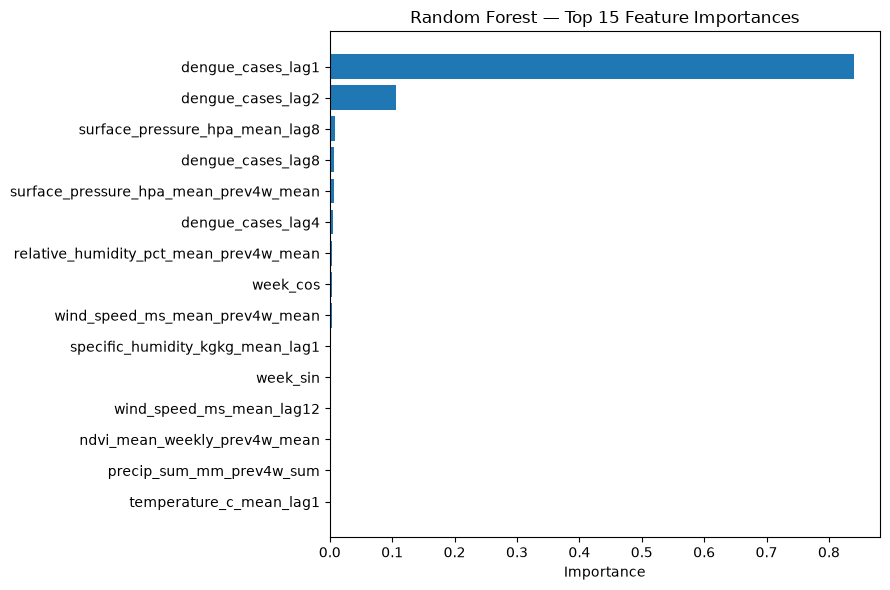

In [62]:
fig, ax = plt.subplots(figsize=(9, 6))

rf_top = rf_importance.head(15).sort_values(
    "importance"
)

ax.barh(
    rf_top["feature"],
    rf_top["importance"]
)

ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [63]:
if XGBOOST_AVAILABLE:

    xgb_key = (
        best_xgb_climate["configuration"],
        "history+climate"
    )

    best_xgb_model = xgb_fitted_models[xgb_key]

    xgb_importance = pd.DataFrame({
        "feature": CLIMATE_ENHANCED_FEATURES,
        "importance": best_xgb_model.feature_importances_,
    })

    xgb_importance["algorithm"] = "XGBoost"

    xgb_importance = xgb_importance.sort_values(
        "importance",
        ascending=False,
    )

    importance_tables.append(xgb_importance)

    display(xgb_importance.head(15))

,feature,importance,algorithm
2,dengue_cases_lag1,0.627415,XGBoost
15,wind_speed_ms_mean_lag12,0.065123,XGBoost
0,week_sin,0.062583,XGBoost
7,precip_sum_mm_lag4,0.057852,XGBoost
9,temperature_c_mean_lag1,0.053497,XGBoost
8,precip_sum_mm_prev4w_sum,0.045191,XGBoost
18,surface_pressure_hpa_mean_lag8,0.022995,XGBoost
16,wind_speed_ms_mean_prev4w_mean,0.020366,XGBoost
1,week_cos,0.007222,XGBoost
6,precip_sum_mm_lag1,0.005976,XGBoost


### Interpretation — XGBoost feature importance

The XGBoost climate-enhanced model uses environmental information more visibly than Random Forest.

`dengue_cases_lag1` remains dominant at approximately **62.7%**, confirming that recent incidence is still the single most important source of predictive information.

However, several environmental and seasonal features receive material importance, including:

- 12-week lagged wind speed;
- annual seasonal sine term;
- 4-week lagged precipitation;
- 1-week lagged temperature;
- previous 4-week precipitation accumulation;
- 8-week lagged surface pressure.

This suggests that XGBoost is using climate variables to refine predictions around the strong autoregressive dengue signal. Nevertheless, because the climate-enhanced XGBoost has worse overall MAE than history-only XGBoost, these importances should not be interpreted as evidence that the added variables improve average forecasting accuracy.

Tree-based feature importance describes how the fitted model uses variables; it does **not** establish causal influence. A later SHAP analysis would provide a more informative interpretation of the selected final model.


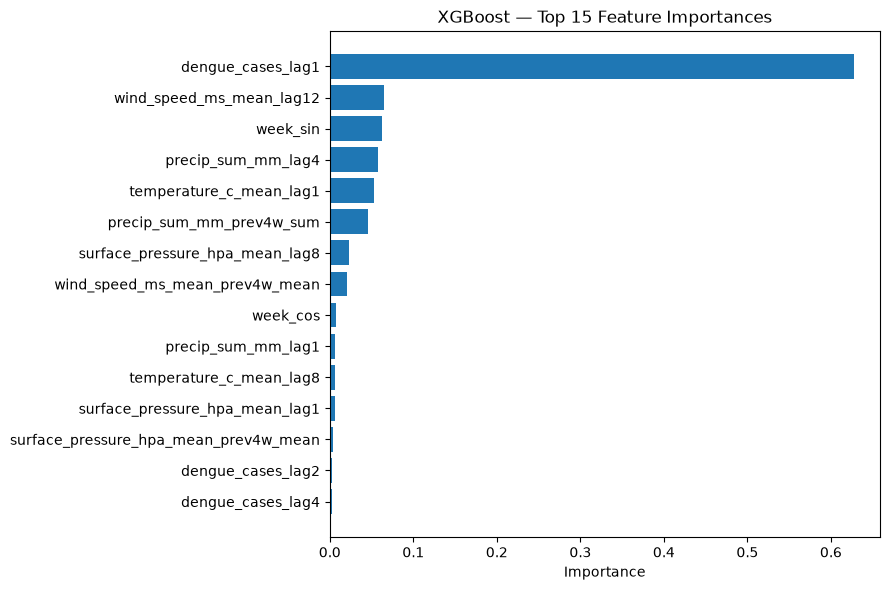

In [64]:
if XGBOOST_AVAILABLE:

    fig, ax = plt.subplots(figsize=(9, 6))

    xgb_top = xgb_importance.head(15).sort_values(
        "importance"
    )

    ax.barh(
        xgb_top["feature"],
        xgb_top["importance"]
    )

    ax.set_title("XGBoost — Top 15 Feature Importances")
    ax.set_xlabel("Importance")

    plt.tight_layout()
    plt.show()

## 14. Save validation-development outputs

Only validation-development outputs are saved. No final test predictions are generated here.

In [65]:
ml_results_df.to_csv(
    OUTPUT_DIR / "ml_validation_all_configs.csv",
    index=False
)

comparison_table.to_csv(
    OUTPUT_DIR / "ml_validation_model_comparison.csv",
    index=False
)

incremental_climate_value.to_csv(
    OUTPUT_DIR / "ml_validation_climate_increment.csv",
    index=False
)

incidence_error_table.to_csv(
    OUTPUT_DIR / "ml_validation_incidence_errors.csv",
    index=False
)

feature_importance_df = pd.concat(
    importance_tables,
    ignore_index=True
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "ml_validation_feature_importance.csv",
    index=False
)

for key, pred_df in rf_predictions.items():
    configuration, feature_set = key

    safe_feature_set = feature_set.replace("+", "_plus_").replace("-", "_")

    pred_df.to_csv(
        OUTPUT_DIR
        / f"rf_{configuration}_{safe_feature_set}_validation_predictions.csv",
        index=False
    )

for key, pred_df in xgb_predictions.items():
    configuration, feature_set = key

    safe_feature_set = feature_set.replace("+", "_plus_").replace("-", "_")

    pred_df.to_csv(
        OUTPUT_DIR
        / f"xgb_{configuration}_{safe_feature_set}_validation_predictions.csv",
        index=False
    )

print("Machine-learning validation outputs saved to outputs/modelling/")

Machine-learning validation outputs saved to outputs/modelling/


## 15. Consolidated interpretation and decision

The development-stage machine-learning results support several conclusions.

### Machine learning versus the simple baselines

The strongest overall validation model is **XGBoost `XGB_3` using history and seasonality only**, with MAE 10.56, RMSE 21.10 and R² 0.912. It outperforms both persistence and the Ridge history + seasonality baseline.

This provides evidence that a flexible non-linear machine-learning model can extract additional predictive information from recent dengue history beyond a simple one-week persistence rule.

### Climate contribution

The contribution of climate is **model-dependent**.

- Random Forest improves materially when climate/environmental features are added.
- XGBoost performs slightly worse overall when the same broader environmental information is added.
- Both algorithms, however, show lower error on the small group of higher-incidence validation weeks when climate variables are included.

Therefore, the current evidence does not support a simple claim that climate always improves one-week-ahead dengue prediction. A more defensible interpretation is that environmental information provides **selective incremental predictive value**, particularly during higher-incidence periods, while recent dengue incidence remains the dominant predictor overall.

### Current preferred ML specification

For overall predictive accuracy, the preferred ML model is:

**XGBoost `XGB_3` — history-only**

The corresponding **XGB_3 history + climate** model should still be retained as the direct climate-comparison specification for H1.

The climate-enhanced Random Forest remains useful supporting evidence that the value of environmental predictors varies by algorithm.

### Next step before final testing

The final 2021–2023 holdout must remain untouched.

The next development-stage step is to compare these ML results with a traditional time-series approach using **SARIMA/SARIMAX**. Once that comparison is complete, the project should freeze:

1. the primary ML model;
2. the climate comparison specification;
3. the preferred traditional time-series model;
4. MAE and RMSE as the evaluation metrics;
5. the final refitting procedure using all data available through 2020.

Only then should the selected models be evaluated once on the 2021–2023 final test period.
